In [1]:
# !pip install google-cloud-bigquery\


# Guide



## generate data 

In [2]:
# -----######-----######-----######-----######-----######
# SQL LEARNING DATASET GENERATOR
# -----######-----######-----######-----######-----######

import pandas as pd
import numpy as np
from tqdm import tqdm

# ----- MAIN FUNCTION -----
def _sql_1104_i1_GET_df_sample():
    
    np.random.seed(42)
    
    n_orders = 5000
    n_customers = 300
    n_products = 50

    # -----------------------------
    # CUSTOMERS TABLE
    # -----------------------------
    df_customers = pd.DataFrame({
        "customer_id": np.arange(1, n_customers+1),
        "customer_name": [f"cust_{i}" for i in range(1, n_customers+1)],
        "country": np.random.choice(["USA", "Canada", "Mexico"], n_customers),
        "signup_date": pd.to_datetime("2022-01-01") + pd.to_timedelta(
            np.random.randint(0, 1000, n_customers), unit="D"
        )
    })

    # -----------------------------
    # PRODUCTS TABLE
    # -----------------------------
    df_products = pd.DataFrame({
        "product_id": np.arange(1, n_products+1),
        "product_name": [f"prod_{i}" for i in range(1, n_products+1)],
        "category": np.random.choice(["Audio", "Tech", "Accessories"], n_products),
        "price": np.round(np.random.uniform(5, 500, n_products), 2)
    })

    # -----------------------------
    # ORDERS TABLE
    # -----------------------------
    orders = []

    for i in tqdm(range(n_orders), desc="Generating Orders"):
        cust = np.random.randint(1, n_customers+1)
        prod = np.random.randint(1, n_products+1)
        quantity = np.random.randint(1, 5)

        orders.append([
            i+1,
            cust,
            prod,
            quantity,
            pd.to_datetime("2023-01-01") + pd.to_timedelta(
                np.random.randint(0, 365), unit="D"
            )
        ])

    df_orders = pd.DataFrame(orders, columns=[
        "order_id",
        "customer_id",
        "product_id",
        "quantity",
        "order_date"
    ])

    # -----------------------------
    # DERIVED FEATURES (VERY IMPORTANT FOR SQL LEARNING)
    # -----------------------------
    df_orders = df_orders.merge(df_products[["product_id", "price"]], on="product_id")

    df_orders["revenue"] = df_orders["quantity"] * df_orders["price"]

    # introduce anomalies (for SQL filtering practice)
    anomaly_idx = np.random.choice(df_orders.index, size=50, replace=False)
    df_orders.loc[anomaly_idx, "revenue"] *= 5

    return df_customers, df_products, df_orders

In [107]:
#!#!#!#!#! RUNNING STATEMENTS #!#!#!#!#!

df_customers, df_products, df_orders = _sql_1104_i1_GET_df_sample()

df_orders#.head()

Generating Orders: 100%|████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 9183.94it/s]


,order_id,customer_id,product_id,quantity,order_date,price,revenue
0,1,275,44,2,2023-06-16,432.25,864.50
1,90,173,44,1,2023-11-22,432.25,432.25
2,101,69,44,2,2023-11-30,432.25,864.50
3,173,226,44,3,2023-12-08,432.25,1296.75
4,202,229,44,4,2023-04-12,432.25,1729.00
...,...,...,...,...,...,...,...
4995,4644,241,7,2,2023-03-20,54.49,108.98
4996,4700,35,7,1,2023-03-18,54.49,272.45
4997,4806,87,7,2,2023-06-10,54.49,108.98
4998,4844,245,7,1,2023-09-17,54.49,54.49


In [108]:
df_products.head()

,product_id,product_name,category,price
0,1,prod_1,Tech,122.93
1,2,prod_2,Accessories,191.98
2,3,prod_3,Audio,269.49
3,4,prod_4,Audio,250.80
4,5,prod_5,Accessories,197.86


In [109]:
df_customers

,customer_id,customer_name,country,signup_date
0,1,cust_1,Mexico,2022-06-12
1,2,cust_2,USA,2023-12-21
2,3,cust_3,Mexico,2024-08-14
3,4,cust_4,Mexico,2023-11-12
4,5,cust_5,USA,2024-09-22
...,...,...,...,...
295,296,cust_296,Canada,2023-09-05
296,297,cust_297,Canada,2022-09-25
297,298,cust_298,Canada,2024-04-14
298,299,cust_299,Canada,2023-07-31


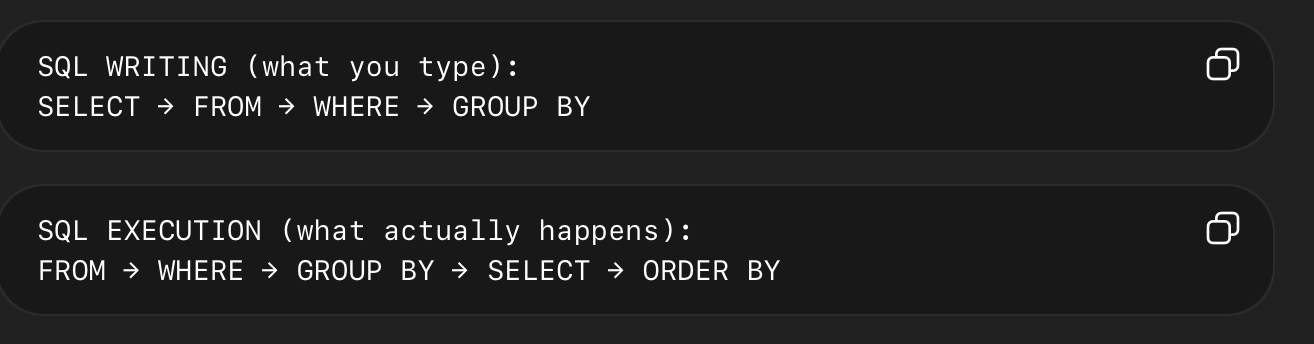

# SQL 

### * SELECT   >>> is written at the beggining but executed at the end 

### * GROUP BY >>> tells you for what the select function is 
* customer_id is what tells SQL how to group

In [110]:
import duckdb

con = duckdb.connect()

def q(sql):
    print(f":::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :\n*\n* {sql}*\n*")
    return con.execute(sql).df()

con.register("orders", df_orders)
con.register("customers", df_customers)
con.register("products", df_products)

In [111]:
 q("SELECT * FROM orders LIMIT 5")

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* SELECT * FROM orders LIMIT 5*
*


,order_id,customer_id,product_id,quantity,order_date,price,revenue
0,1,275,44,2,2023-06-16,432.25,864.50
1,90,173,44,1,2023-11-22,432.25,432.25
2,101,69,44,2,2023-11-30,432.25,864.50
3,173,226,44,3,2023-12-08,432.25,1296.75
4,202,229,44,4,2023-04-12,432.25,1729.00


In [112]:
sq_12 = q("""
SELECT *
FROM df_orders
WHERE revenue > 100
""");print(len(sq_12));print("*\n* ::: Rows in SELECTED df head :::: ::: ::: ::: ::: :: :: :: : : : SELECT + WHERE (FOUNDATION)\n");print(sq_12.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 
SELECT *
FROM df_orders
WHERE revenue > 100
*
*
4688
*
* ::: Rows in SELECTED df head :::: ::: ::: ::: ::: :: :: :: : : : SELECT + WHERE (FOUNDATION)

   order_id  customer_id  product_id  quantity order_date   price  revenue
0         1          275          44         2 2023-06-16  432.25   864.50
1        90          173          44         1 2023-11-22  432.25   432.25
2       101           69          44         2 2023-11-30  432.25   864.50
3       173          226          44         3 2023-12-08  432.25  1296.75
4       202          229          44         4 2023-04-12  432.25  1729.00


In [113]:
sq_13 = q("""
SELECT customer_id, revenue, order_date
FROM df_orders
WHERE revenue > 150
ORDER BY revenue DESC
""");print(len(sq_13));print("*\n* ::: Rows in SELECTED df head :::: ::: ::: ::: ::: :: :: :: : : : SELECT specific columns + filter \n");print(sq_13.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 
SELECT customer_id, revenue, order_date
FROM df_orders
WHERE revenue > 150
ORDER BY revenue DESC
*
*
4409
*
* ::: Rows in SELECTED df head :::: ::: ::: ::: ::: :: :: :: : : : SELECT specific columns + filter 

   customer_id  revenue order_date
0            5   9959.8 2023-07-17
1          128   9467.4 2023-07-12
2           65   9316.2 2023-07-20
3          288   9316.2 2023-09-26
4          154   8929.8 2023-06-10


In [114]:
sq_14 = q("""
SELECT 
    customer_id,
    SUM(revenue) AS total_revenue
FROM df_orders
GROUP BY customer_id
ORDER BY total_revenue DESC
""");print(len(sq_14));print("*\n* ::: Rows in SELECTED df head :::: ::: ::: ::: ::: :: :: :: : : : Sum by client ID \n");print(sq_14.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 
SELECT 
    customer_id,
    SUM(revenue) AS total_revenue
FROM df_orders
GROUP BY customer_id
ORDER BY total_revenue DESC
*
*
300
*
* ::: Rows in SELECTED df head :::: ::: ::: ::: ::: :: :: :: : : : Sum by client ID 

   customer_id  total_revenue
0          164       23896.77
1          288       23309.73
2          154       22950.09
3            5       22201.99
4           65       22149.76


In [115]:
sq_15 = q("""
SELECT 
    c.customer_name,
    SUM(o.revenue) AS total_revenue
FROM df_orders o
JOIN df_customers c
    ON o.customer_id = c.customer_id
GROUP BY c.customer_name
ORDER BY total_revenue DESC
""");print(len(sq_15));print("*\n* ::: Rows in SELECTED df head :::: ::: ::: ::: ::: :: :: :: : : : JOIN \n");print(sq_15.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 
SELECT 
    c.customer_name,
    SUM(o.revenue) AS total_revenue
FROM df_orders o
JOIN df_customers c
    ON o.customer_id = c.customer_id
GROUP BY c.customer_name
ORDER BY total_revenue DESC
*
*
300
*
* ::: Rows in SELECTED df head :::: ::: ::: ::: ::: :: :: :: : : : JOIN 

  customer_name  total_revenue
0      cust_164       23896.77
1      cust_288       23309.73
2      cust_154       22950.09
3        cust_5       22201.99
4       cust_65       22149.76


In [116]:
sq_16 = q("""
SELECT 
    DATE_TRUNC('month', order_date) AS month,
    SUM(revenue) AS total_revenue
FROM df_orders
GROUP BY month
ORDER BY month
""");print(len(sq_16));print("*\n* ::: Rows in SELECTED df head ::: Monthly revenue \n");print(sq_16.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 
SELECT 
    DATE_TRUNC('month', order_date) AS month,
    SUM(revenue) AS total_revenue
FROM df_orders
GROUP BY month
ORDER BY month
*
*
12
*
* ::: Rows in SELECTED df head ::: Monthly revenue 

       month  total_revenue
0 2023-01-01      318422.01
1 2023-02-01      258530.40
2 2023-03-01      297753.57
3 2023-04-01      281883.99
4 2023-05-01      295102.47


In [117]:
sq_17 = q("""
SELECT 
    customer_id,
    revenue,
    RANK() OVER (ORDER BY revenue DESC) AS rank
FROM df_orders

""");print(len(sq_17), "::: Rows in SELECTED df head ::: :: :: :: : : : *** Ranking orders *** ::: topic \n");print(sq_17.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 
SELECT 
    customer_id,
    revenue,
    RANK() OVER (ORDER BY revenue DESC) AS rank
FROM df_orders

*
*
5000 ::: Rows in SELECTED df head ::: :: :: :: : : : *** Ranking orders *** ::: topic 

   customer_id  revenue  rank
0            5   9959.8     1
1          128   9467.4     2
2           65   9316.2     3
3          288   9316.2     3
4          154   8929.8     5


In [122]:
sq_18 = q("""
SELECT 
    customer_id,
    SUM(revenue) AS total_revenue
FROM df_orders
GROUP BY customer_id
HAVING SUM(revenue) > 1000
ORDER BY total_revenue DESC
""");print(len(sq_18), "::: Rows in SELECTED df head ::: :: :: :: : : : *** High value customers (HAVING) *** ::: topic \n");print(sq_18.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 
SELECT 
    customer_id,
    SUM(revenue) AS total_revenue
FROM df_orders
GROUP BY customer_id
HAVING SUM(revenue) > 1000
ORDER BY total_revenue DESC
*
*
300 ::: Rows in SELECTED df head ::: :: :: :: : : : *** High value customers (HAVING) *** ::: topic 

   customer_id  total_revenue
0          164       23896.77
1          288       23309.73
2          154       22950.09
3            5       22201.99
4           65       22149.76


In [123]:
sq_19 = q("""
SELECT 
    p.category,
    SUM(o.revenue) AS total_revenue
FROM df_orders o
JOIN df_products p
    ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY total_revenue DESC
""");print(len(sq_19), "::: Rows in SELECTED df head ::: :: :: :: : : : *** Revenue by category (JOIN) *** ::: topic \n");print(sq_19.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 
SELECT 
    p.category,
    SUM(o.revenue) AS total_revenue
FROM df_orders o
JOIN df_products p
    ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY total_revenue DESC
*
*
3 ::: Rows in SELECTED df head ::: :: :: :: : : : *** Revenue by category (JOIN) *** ::: topic 

      category  total_revenue
0        Audio     1572663.37
1  Accessories     1036222.59
2         Tech      995007.61


In [124]:
sq_20 = q("""
SELECT *
FROM (
    SELECT 
        customer_id,
        SUM(revenue) AS total_revenue
    FROM df_orders
    GROUP BY customer_id
) t
WHERE total_revenue > (
    SELECT AVG(total_revenue)
    FROM (
        SELECT 
            customer_id,
            SUM(revenue) AS total_revenue
        FROM df_orders
        GROUP BY customer_id
    )
)
""");print(len(sq_20), "::: Rows in SELECTED df head ::: :: :: :: : : : *** Above avg customers (Subquery) *** ::: topic \n");print(sq_20.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 
SELECT *
FROM (
    SELECT 
        customer_id,
        SUM(revenue) AS total_revenue
    FROM df_orders
    GROUP BY customer_id
) t
WHERE total_revenue > (
    SELECT AVG(total_revenue)
    FROM (
        SELECT 
            customer_id,
            SUM(revenue) AS total_revenue
        FROM df_orders
        GROUP BY customer_id
    )
)
*
*
141 ::: Rows in SELECTED df head ::: :: :: :: : : : *** Above avg customers (Subquery) *** ::: topic 

   customer_id  total_revenue
0          249       13436.73
1           31       13509.36
2           15       19448.95
3          163       12543.47
4           22       17151.91


In [125]:
sq_21 = q("""
SELECT 
    customer_id,
    COUNT(*) AS num_orders,
    AVG(revenue) AS avg_order_value
FROM df_orders
GROUP BY customer_id
ORDER BY avg_order_value DESC
""");print(len(sq_21), "::: Rows in SELECTED df head ::: :: :: :: : : : *** Customer behavior (COUNT + AVG) *** ::: topic \n");print(sq_21.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 
SELECT 
    customer_id,
    COUNT(*) AS num_orders,
    AVG(revenue) AS avg_order_value
FROM df_orders
GROUP BY customer_id
ORDER BY avg_order_value DESC
*
*
300 ::: Rows in SELECTED df head ::: :: :: :: : : : *** Customer behavior (COUNT + AVG) *** ::: topic 

   customer_id  num_orders  avg_order_value
0           96          12      1485.672500
1          232          13      1216.054615
2           30          12      1194.602500
3           65          19      1165.776842
4          288          20      1165.486500


In [126]:
sq_22 = q("""
SELECT 
    customer_id,
    revenue,
    RANK() OVER (PARTITION BY customer_id ORDER BY revenue DESC) AS rank_within_customer
FROM df_orders
""");print(len(sq_22), "::: Rows in SELECTED df head ::: :: :: :: : : : *** Rank within customer (WINDOW PARTITION) *** ::: topic \n");print(sq_22.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 
SELECT 
    customer_id,
    revenue,
    RANK() OVER (PARTITION BY customer_id ORDER BY revenue DESC) AS rank_within_customer
FROM df_orders
*
*
5000 ::: Rows in SELECTED df head ::: :: :: :: : : : *** Rank within customer (WINDOW PARTITION) *** ::: topic 

   customer_id  revenue  rank_within_customer
0           53  4469.70                     1
1           53  1917.92                     2
2           53  1420.11                     3
3           53  1260.15                     4
4           53  1116.32                     5


# Show all orders where:
# revenue > 200
# Columns:
# customer_id
# revenue

In [129]:
sq_test_1 = q("""
SELECT 
    customer_id,
    revenue
FROM df_orders
WHERE revenue > 200
""");print(len(sq_test_1), "::: Rows :::");print(sq_test_1.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 
SELECT 
    customer_id,
    revenue
FROM df_orders
WHERE revenue > 200
*
*
4165 ::: Rows :::
   customer_id  revenue
0          275   864.50
1          173   432.25
2           69   864.50
3          226  1296.75
4          229  1729.00


<!-- Show:
total revenue per customer
Columns:
customer_id
total_revenue
Sort:
highest revenue first -->

# Show:
# total revenue per customer
# Columns:
# customer_id
# total_revenue
# Sort:
# highest revenue first

In [136]:
sq_test_1 = q("""

SELECT
    SUM(revenue) AS total_revenue,
    customer_id
FROM df_orders
GROUP BY customer_id
ORDER BY total_revenue DESC

""");print(len(sq_test_1), "::: Rows :::");print(sq_test_1.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 

SELECT
    SUM(revenue) AS total_revenue,
    customer_id
FROM df_orders
GROUP BY customer_id
ORDER BY total_revenue DESC

*
*
300 ::: Rows :::
   total_revenue  customer_id
0       23896.77          164
1       23309.73          288
2       22950.09          154
3       22201.99            5
4       22149.76           65


In [137]:
sq_test_1 = q("""

SELECT
    customer_id,
    SUM(revenue) AS total_revenue
FROM df_orders
GROUP BY customer_id
ORDER BY total_revenue DESC

""");print(len(sq_test_1), "::: Rows :::");print(sq_test_1.head())

:::: ::: ::: ::: ::: :: :: :: : : ::::: ::: ::: ::: ::: :: :: :: : : :
*
* 

SELECT
    customer_id,

    SUM(revenue) AS total_revenue
FROM df_orders
GROUP BY customer_id
ORDER BY total_revenue DESC

*
*
300 ::: Rows :::
   customer_id  total_revenue
0          164       23896.77
1          288       23309.73
2          154       22950.09
3            5       22201.99
4           65       22149.76


In [118]:
df_customers

,customer_id,customer_name,country,signup_date
0,1,cust_1,Mexico,2022-06-12
1,2,cust_2,USA,2023-12-21
2,3,cust_3,Mexico,2024-08-14
3,4,cust_4,Mexico,2023-11-12
4,5,cust_5,USA,2024-09-22
...,...,...,...,...
295,296,cust_296,Canada,2023-09-05
296,297,cust_297,Canada,2022-09-25
297,298,cust_298,Canada,2024-04-14
298,299,cust_299,Canada,2023-07-31


In [121]:
#df_products 50 products

In [104]:
df_orders

,order_id,customer_id,product_id,quantity,order_date,price,revenue
0,1,275,44,2,2023-06-16,432.25,864.50
1,90,173,44,1,2023-11-22,432.25,432.25
2,101,69,44,2,2023-11-30,432.25,864.50
3,173,226,44,3,2023-12-08,432.25,1296.75
4,202,229,44,4,2023-04-12,432.25,1729.00
...,...,...,...,...,...,...,...
4995,4644,241,7,2,2023-03-20,54.49,108.98
4996,4700,35,7,1,2023-03-18,54.49,272.45
4997,4806,87,7,2,2023-06-10,54.49,108.98
4998,4844,245,7,1,2023-09-17,54.49,54.49


In [8]:
import duckdb

con = duckdb.connect()

con.register("orders", df_orders)
con.register("customers", df_customers)
con.register("products", df_products)

In [9]:
con.execute("""
SELECT *
FROM orders
WHERE revenue > 100
""").df()

,order_id,customer_id,product_id,quantity,order_date,price,revenue
0,1,275,44,2,2023-06-16,432.25,864.50
1,90,173,44,1,2023-11-22,432.25,432.25
2,101,69,44,2,2023-11-30,432.25,864.50
3,173,226,44,3,2023-12-08,432.25,1296.75
4,202,229,44,4,2023-04-12,432.25,1729.00
...,...,...,...,...,...,...,...
4683,4510,82,7,4,2023-02-17,54.49,217.96
4684,4609,271,7,3,2023-12-13,54.49,163.47
4685,4644,241,7,2,2023-03-20,54.49,108.98
4686,4700,35,7,1,2023-03-18,54.49,272.45
